In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import re
import unicodedata

In [4]:
path="C:/Users/CD44/Desktop/Narval.xlsx"
path_="C:/Users/CD44/Desktop/narvalentier.xlsx"

In [5]:
df = pd.read_excel(path)
df_totale=pd.read_excel(path_)

In [6]:
df.shape

(15535, 7)

In [7]:
df.head()

,Numéro fiche,Numéro de dossier,Matériaux,Matériaux complémentaires,Description traitement,Traitement de la demande,Photo pendant le traitement
0,000000001,00000001,crêpes,NaN,NaN,NaN,NaN
1,0000002,00000001,crêpes,NaN,NaN,NaN,NaN
2,0000002,00000001,crêpes,NaN,NaN,NaN,NaN
3,000065,00000001,crêpes,NaN,NaN,NaN,NaN
4,1313156,D124-747/98,NaN,NaN,NaN,NaN,NaN


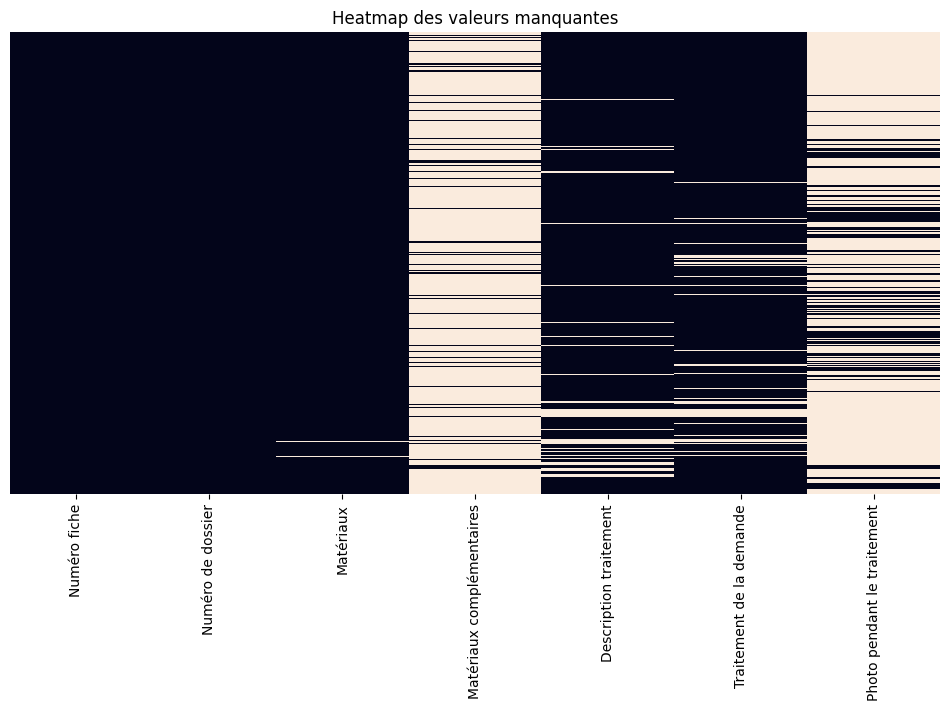

In [8]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title("Heatmap des valeurs manquantes")
plt.show()


Fusion de "Matériaux complémentaires" et "Matériaux"

In [9]:
df["Matériaux"]=df[["Matériaux", "Matériaux complémentaires"]].apply(
    lambda x: " | ".join(x.dropna().astype(str)),
    axis=1
)
df=df.drop("Matériaux complémentaires",axis=1)

In [10]:
df.head()

,Numéro fiche,Numéro de dossier,Matériaux,Description traitement,Traitement de la demande,Photo pendant le traitement
0,000000001,00000001,crêpes,NaN,NaN,NaN
1,0000002,00000001,crêpes,NaN,NaN,NaN
2,0000002,00000001,crêpes,NaN,NaN,NaN
3,000065,00000001,crêpes,NaN,NaN,NaN
4,1313156,D124-747/98,,NaN,NaN,NaN


NETTOYAGE TEXTUEL

In [11]:
def clean_text(text):
    if pd.isna(text):
        return text
    
    # Forcer le type string
    text = str(text)
    
    # Minuscules
    text = text.lower()
    
    # Suppression des accents
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    
    # Suppression ponctuation / caractères spéciaux
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    
    # Nettoyage espaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

Application sur df colonne par colonne

In [12]:
df["Matériaux"] = df["Matériaux"].apply(clean_text)


In [13]:
df["Description traitement"] = df["Description traitement"].apply(clean_text)


In [14]:
df["Traitement de la demande"] = df["Traitement de la demande"].apply(clean_text)

In [15]:
df["Photo pendant le traitement"] = df["Photo pendant le traitement"].apply(clean_text)

Base de données nettoyée mais en gardant les valeurs NaN

In [16]:
df

,Numéro fiche,Numéro de dossier,Matériaux,Description traitement,Traitement de la demande,Photo pendant le traitement
0,000000001,00000001,crepes,NaN,NaN,NaN
1,0000002,00000001,crepes,NaN,NaN,NaN
2,0000002,00000001,crepes,NaN,NaN,NaN
3,000065,00000001,crepes,NaN,NaN,NaN
4,1313156,D124-747/98,,NaN,NaN,NaN
...,...,...,...,...,...,...
15530,test_objet,D14-81/96,,NaN,NaN,NaN
15531,test_objet,D26-114/95,,NaN,NaN,NaN
15532,testsm,D231-362/17,,NaN,NaN,NaN
15533,testsm,D229-360/17,,NaN,NaN,NaN


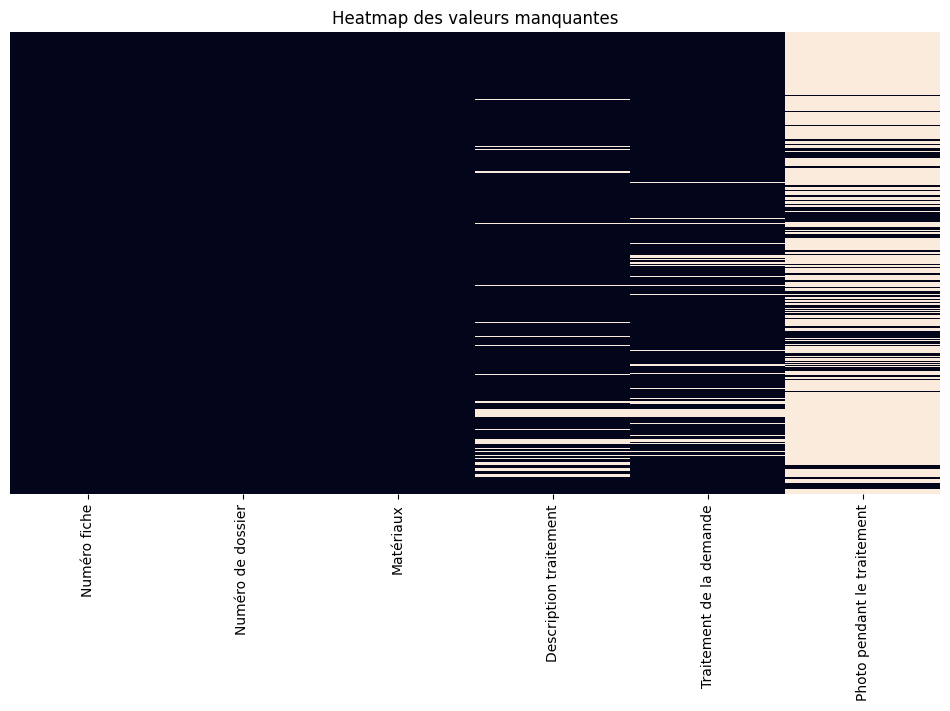

In [17]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title("Heatmap des valeurs manquantes")
plt.show()


On garde que les cuivreux en se basant sur les mots clés : cuivre et cuivreux ( à voir)

In [18]:
#On crée une nouvelle colonne "tout_info" et on y fusionne materiaux et description traitement pour pouvoir rassembler toute l info dans une colonne et faire le tri des elements cuivreux
df["tout_info"]=df[["Matériaux", "Description traitement"]].apply(
    lambda x: " ".join(x.dropna().astype(str)),
    axis=1
)


In [19]:
df_cuivre_Narval = df[df["tout_info"].str.contains(r"\bcuivre\b|\bcuivreux\b|\bbronze\b|\blaiton\b",
                                          case=False, 
                                          na=False)]

In [20]:
df_cuivre_Narval

,Numéro fiche,Numéro de dossier,Matériaux,Description traitement,Traitement de la demande,Photo pendant le traitement,tout_info
7,1990003,D5/90,base cuivre,elimination mecanique des sediments au scalpel...,nettoyage stabilisation protection,NaN,base cuivre elimination mecanique des sediment...
8,1990004,D5/90,base cuivre,leger nettoyage manuel a laide d un coton imbi...,nettoyage stabilisation protection,NaN,base cuivre leger nettoyage manuel a laide d u...
9,1990005,D5/90,base cuivre,elimination mecanique des sediments au scalpel...,nettoyage stabilisation protection,NaN,base cuivre elimination mecanique des sediment...
10,1990006,D5/90,base cuivre,elimination mecanique des sediments residuels ...,nettoyage stabilisation protection,NaN,base cuivre elimination mecanique des sediment...
11,1990007,D5/90,base cuivre,immersion de 24 heures dans lhexametaphosphate...,nettoyage stabilisation protection,NaN,base cuivre immersion de 24 heures dans lhexam...
...,...,...,...,...,...,...,...
14951,2040101,D100-100/19,base cuivre,NaN,NaN,NaN,base cuivre
14952,2040102,D100-100/19,base cuivre,NaN,NaN,NaN,base cuivre
15072,3000116,D8-15/09,base cuivre,depoussierage des surfaces effectue a laide de...,depoussierage nettoyage leger consolidations e...,NaN,base cuivre depoussierage des surfaces effectu...
15384,3000426,D8-15/09,base cuivre,depoussierage des surfaces effectue a laide de...,depoussierage nettoyage leger consolidations e...,NaN,base cuivre depoussierage des surfaces effectu...


In [21]:
df= df.drop("tout_info", axis=1) #on n'a plus besoin de cette colonne

On a reduit le nombre de lignes de 15535 à 5563 ( que les cuivreux) et on garde toujours les NaN

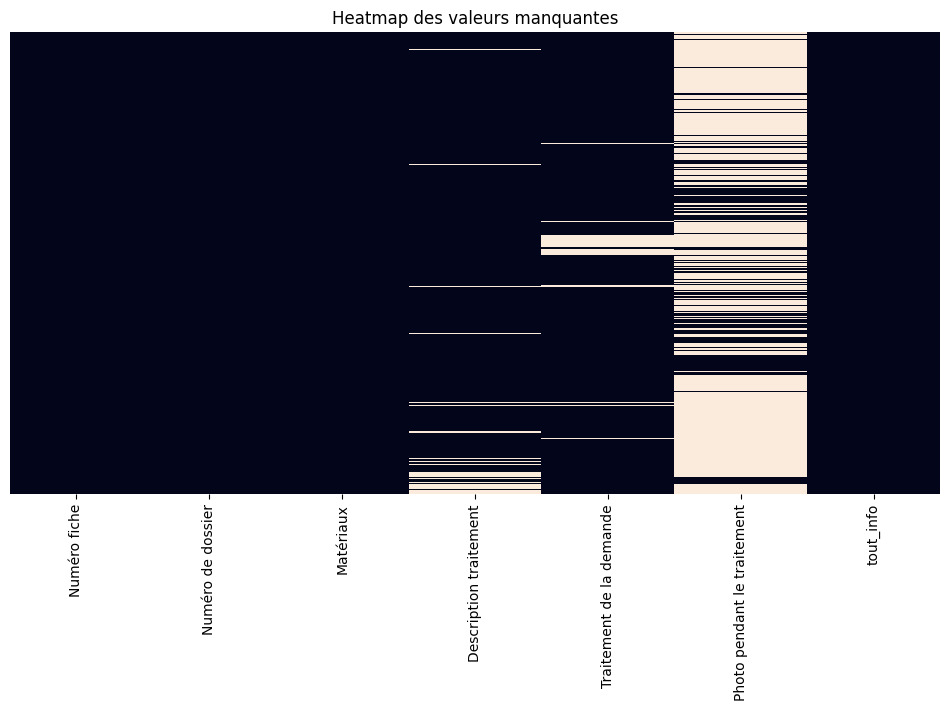

In [22]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_cuivre_Narval.isna(), cbar=False, yticklabels=False)
plt.title("Heatmap des valeurs manquantes")
plt.show()


In [23]:
df

,Numéro fiche,Numéro de dossier,Matériaux,Description traitement,Traitement de la demande,Photo pendant le traitement
0,000000001,00000001,crepes,NaN,NaN,NaN
1,0000002,00000001,crepes,NaN,NaN,NaN
2,0000002,00000001,crepes,NaN,NaN,NaN
3,000065,00000001,crepes,NaN,NaN,NaN
4,1313156,D124-747/98,,NaN,NaN,NaN
...,...,...,...,...,...,...
15530,test_objet,D14-81/96,,NaN,NaN,NaN
15531,test_objet,D26-114/95,,NaN,NaN,NaN
15532,testsm,D231-362/17,,NaN,NaN,NaN
15533,testsm,D229-360/17,,NaN,NaN,NaN


In [58]:
df_cuivre_Narval.shape

(5563, 10)

In [24]:
# Colonnes textuelles à analyser
TEXT_COLUMNS = ["Matériaux", "Description traitement"]  

keywords = {
    3: ["chalco","chalconatronite","chalconatronitre"], #poids fort
    2: ["Chlorure","Dégradation","Altération","Corrosion localisée","Corrosion verte","Corrosion active","Produit de corrosion bleu-vert","bleu-vert","Pulvérulent","Pulvérulence","Récurrence cyclique","Corrosion pulvérulente","Sels verts"],   # poids moyen
    1: ["Archéologie","Sculpture","Croyance","Croyances-coutumes","Statuette","Statue","Amulette","Monnaie","Basse époque","Époque ptolémaïque","Antiquité","Égypte","Moyen Orient","Pratique votive","Fonte à la cire perdue","Coulé","Cire perdue","Stabilisé","Oxydes d'argent","Protection de la surface : Paraloïd B72 à 5%"
,"Paraloïd B72 à 5%","oxydation","stabilisation chimique"],# poids faible
}


In [25]:
keywords = {
    k: [clean_text(mot) for mot in liste]
    for k, liste in keywords.items()
}

In [26]:
keywords

{3: ['chalco', 'chalconatronite', 'chalconatronitre'],
 2: ['chlorure',
  'degradation',
  'alteration',
  'corrosion localisee',
  'corrosion verte',
  'corrosion active',
  'produit de corrosion bleu vert',
  'bleu vert',
  'pulverulent',
  'pulverulence',
  'recurrence cyclique',
  'corrosion pulverulente',
  'sels verts'],
 1: ['archeologie',
  'sculpture',
  'croyance',
  'croyances coutumes',
  'statuette',
  'statue',
  'amulette',
  'monnaie',
  'basse epoque',
  'epoque ptolemaique',
  'antiquite',
  'egypte',
  'moyen orient',
  'pratique votive',
  'fonte a la cire perdue',
  'coule',
  'cire perdue',
  'stabilise',
  'oxydes d argent',
  'protection de la surface paraloid b72 a 5',
  'paraloid b72 a 5',
  'oxydation',
  'stabilisation chimique']}

In [27]:
# Seuil de détection 
#   - 1 mot de poids 2             → score = 2  
#   - 2 mots de poids 1            → score = 2  
#   - 1 mot poids 2 + 1 mot poids 1 → score = 3  
SEUIL = 2

In [28]:
# Fonction de scoring 
def calculer_score(row):
    # Concaténer toutes les colonnes textuelles en une seule chaîne
    texte = " ".join(
        str(row[col]).lower() for col in TEXT_COLUMNS if col in row.index
    )
    
    score = 0
    details = []
    
    for poids, mots in keywords.items():
        for mot in mots:
            pattern = r'\b' + re.escape(mot.lower()) + r'\b'
            if re.search(pattern, texte):
                score += poids
                details.append(f"'{mot}' (poids {poids})")
    
    return score, "; ".join(details)

In [29]:
# Application sur le DataFrame 
df_cuivre_Narval[["score_chalco", "mots_detectes"]] = df_cuivre_Narval.apply(
    lambda row: pd.Series(calculer_score(row)), axis=1
)

In [30]:
# Détection finale 
df_cuivre_Narval["est_chalco"] = df_cuivre_Narval["score_chalco"] >= SEUIL

In [31]:
#Résultats 
print(f"Éléments détectés comme 'chalconatronite' : {df_cuivre_Narval['est_chalco'].sum()} / {len(df_cuivre_Narval)}")
print(f"Non détectés             : {(~df_cuivre_Narval['est_chalco']).sum()}")
print(df_cuivre_Narval[df_cuivre_Narval["est_chalco"]][["score_chalco", "mots_detectes"]].head(10))


Éléments détectés comme 'chalconatronite' : 170 / 5563
Non détectés             : 5393
     score_chalco                                      mots_detectes
12              3  'alteration' (poids 2); 'paraloid b72 a 5' (po...
103             2                             'alteration' (poids 2)
130             2                             'alteration' (poids 2)
131             2                             'alteration' (poids 2)
132             2                             'alteration' (poids 2)
133             2                             'alteration' (poids 2)
244             3  'corrosion active' (poids 2); 'paraloid b72 a ...
265             2                       'corrosion active' (poids 2)
270             2                       'corrosion active' (poids 2)
274             2                       'corrosion active' (poids 2)


138 elem ayant score >= 2 et
7 elem ayant score >= 3

In [32]:
# Export
#df_cuivre_Narval.to_excel("resultats_detection.xlsx", index=False)

<Axes: >

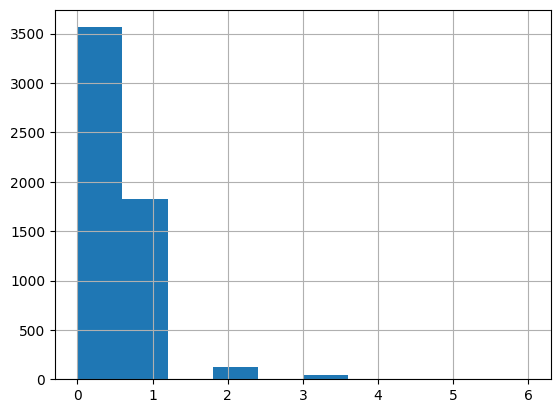

In [33]:
df_cuivre_Narval["score_chalco"].hist()

In [34]:
df_cuivre_Narval[df_cuivre_Narval["est_chalco"]]

,Numéro fiche,Numéro de dossier,Matériaux,Description traitement,Traitement de la demande,Photo pendant le traitement,tout_info,score_chalco,mots_detectes,est_chalco
12,1990008,D5/90,base cuivre,elimination des sediments superficiels au scal...,nettoyage stabilisation protection,NaN,base cuivre elimination des sediments superfic...,3,'alteration' (poids 2); 'paraloid b72 a 5' (po...,True
103,1991001,HORS DEVIS,base cuivre,decapage mecanique des produits d alteration s...,nettoyage stabilisation protection,NaN,base cuivre decapage mecanique des produits d ...,2,'alteration' (poids 2),True
130,1991029,D5-68/91,base cuivre,retablissement d une impression de planeite ge...,nettoyage stabilisation protection,NaN,base cuivre retablissement d une impression de...,2,'alteration' (poids 2),True
131,1991030,D5-68/91,base cuivre,elimination manuelle scalpel et microtour sous...,nettoyage stabilisation protection,NaN,base cuivre elimination manuelle scalpel et mi...,2,'alteration' (poids 2),True
132,1991031,D5-68/91,base cuivre,elimination manuelle au scalpel et mecanique s...,nettoyage stabilisation protection,NaN,base cuivre elimination manuelle au scalpel et...,2,'alteration' (poids 2),True
...,...,...,...,...,...,...,...,...,...,...
12637,2013343,D132-260/13,base cuivre,nettoyage mecanique par micro sablage au ligno...,nettoyage stabilisation protection,NaN,base cuivre nettoyage mecanique par micro sabl...,2,'stabilise' (poids 1); 'paraloid b72 a 5' (poi...,True
12638,2013344,D132-260/13,base cuivre,nettoyage mecanique des faces par utilisation ...,nettoyage stabilisation protection,NaN,base cuivre nettoyage mecanique des faces par ...,2,'stabilise' (poids 1); 'paraloid b72 a 5' (poi...,True
12639,2013345,D132-260/13,base cuivre,les globules ont ete enleves mecaniquement a l...,nettoyage stabilisation protection,NaN,base cuivre les globules ont ete enleves mecan...,2,'stabilise' (poids 1); 'paraloid b72 a 5' (poi...,True
13261,2014157,D71-125/14,base cuivre,elimination du sediment residuel par des moyen...,nettoyage stabilisation protection,NaN,base cuivre elimination du sediment residuel p...,2,'corrosion active' (poids 2),True


In [54]:
valeurs_uniques = df_cuivre_Narval['mots_detectes'].unique()
valeurs_uniques

<StringArray>
[                                                               ''paraloid b72 a 5' (poids 1)',
                                                                                            '',
                                        ''alteration' (poids 2); 'paraloid b72 a 5' (poids 1)',
                                                                      ''alteration' (poids 2)',
                                  ''corrosion active' (poids 2); 'paraloid b72 a 5' (poids 1)',
                                                                ''corrosion active' (poids 2)',
                                                                       ''oxydation' (poids 1)',
                                          ''chlorure' (poids 2); 'paraloid b72 a 5' (poids 1)',
                                                             ''corrosion localisee' (poids 2)',
                                                                        ''chlorure' (poids 2)',
                          

=>Mots détectés: ["Corrosion active" & 'Corrosion verte']=> poids= 2 |||   ["Monnaie" & "Statuette" & "Statue"]=> poids= 1

In [55]:
elem_chalco= df_cuivre_Narval[df_cuivre_Narval["mots_detectes"].str.contains(r'chalconatronite',
                                          case=False, 
                                          na=False)]
elem_chalco

,Numéro fiche,Numéro de dossier,Matériaux,Description traitement,Traitement de la demande,Photo pendant le traitement,tout_info,score_chalco,mots_detectes,est_chalco
11683,2011475,Hors Devis,base cuivre,objet traite au moins deux fois pour le meme p...,reprise de corrosion,NaN,base cuivre objet traite au moins deux fois po...,6,'chalconatronite' (poids 3); 'chalconatronitre...,True


=> Un seul elem detecte chalco et pas 3

In [56]:
elem_chlorure= df_cuivre_Narval[df_cuivre_Narval["mots_detectes"].str.contains(r'chlorure',
                                          case=False, 
                                          na=False)]
elem_chlorure

,Numéro fiche,Numéro de dossier,Matériaux,Description traitement,Traitement de la demande,Photo pendant le traitement,tout_info,score_chalco,mots_detectes,est_chalco
348,1992041,D49/90,base cuivre etain,nettoyage par immersion dans une solution aque...,nettoyage stabilisation protection,NaN,base cuivre etain nettoyage par immersion dans...,3,'chlorure' (poids 2); 'paraloid b72 a 5' (poid...,True
2061,1996343,D70-447/96,base cuivre,bain de metaphosphate de sodium a 10 chauffe e...,nettoyage stabilisation protection,NaN,base cuivre bain de metaphosphate de sodium a ...,2,'chlorure' (poids 2),True
3901,1999643,D3-5/99,base cuivre base fer,a leur arrivee au laboratoire lensemble des pi...,degangage stabilisation electrolytique protect...,oui,base cuivre base fer a leur arrivee au laborat...,2,'chlorure' (poids 2),True
3902,1999644,D3-5/99,base cuivre base fer cordage,a leur arrivee au laboratoire lensemble des pi...,degangage stabilisation electrolytique protect...,oui,base cuivre base fer cordage a leur arrivee au...,2,'chlorure' (poids 2),True
3903,1999645,D3-5/99,base cuivre base fer,a leur arrivee au laboratoire lensemble des pi...,degangage stabilisation electrolytique protect...,oui,base cuivre base fer a leur arrivee au laborat...,2,'chlorure' (poids 2),True
5481,2002286,D109-512/02,base cuivre,stabilisation electrolytique en mode potentios...,stabilisation nettoyage protection,NaN,base cuivre stabilisation electrolytique en mo...,3,'chlorure' (poids 2); 'paraloid b72 a 5' (poid...,True
7632,2005467,D98-319/05,base cuivre,elimination des numeros d inventaire existants...,NaN,NaN,base cuivre elimination des numeros d inventai...,2,'chlorure' (poids 2),True
9440,2008339,D138-361/09,base fer bois plomb cuir concretion marine,a reprendrelobjet est conserve dans de leau os...,stockage et estimation devisconstat d etat rad...,de travail mm et syl numeriques 21 04 2010 jga...,base fer bois plomb cuir concretion marine a r...,2,'chlorure' (poids 2),True
9504,2008403,D138-361/09,base cuivre bois,stockage dechloruration lobjet est conserve da...,stockage et estimation devisstabilisation par ...,numeriques de travail syl,base cuivre bois stockage dechloruration lobje...,3,'chlorure' (poids 2); 'paraloid b72 a 5' (poid...,True
10604,2009759,D65-125/11,fer forge cuivreux bois,degangage electrolytique realise avec lancre 2...,degangage dechloruration electrolytique restau...,oui,fer forge cuivreux bois degangage electrolytiq...,2,'chlorure' (poids 2),True


In [41]:
elem_chlorure.shape

(11, 10)

In [57]:
elem_Corrosion_verte= df_cuivre_Narval[df_cuivre_Narval["mots_detectes"].str.contains(r'Corrosion verte',
                                          case=False, 
                                          na=False)]
elem_Corrosion_verte

,Numéro fiche,Numéro de dossier,Matériaux,Description traitement,Traitement de la demande,Photo pendant le traitement,tout_info,score_chalco,mots_detectes,est_chalco
2131,1996413,D76-478/96,base cuivre or,elimination des depots de cire aux abrasifs ve...,nettoyage protection,oui format 135 inversible,base cuivre or elimination des depots de cire ...,2,'corrosion verte' (poids 2),True


In [44]:
elem_Corrosion_active = df_cuivre_Narval[df_cuivre_Narval["mots_detectes"].str.contains(r'Corrosion active',
                                          case=False, 
                                          na=False)]

In [45]:
elem_Corrosion_active

,Numéro fiche,Numéro de dossier,Matériaux,Description traitement,Traitement de la demande,Photo pendant le traitement,tout_info,score_chalco,mots_detectes,est_chalco
244,1991144,D47/90,base cuivre,premier nettoyage par immersions prolongees en...,nettoyage stabilisation protection,NaN,base cuivre premier nettoyage par immersions p...,3,'corrosion active' (poids 2); 'paraloid b72 a ...,True
265,1991165,D16-357/91,base cuivre,elimination du vernis a laide d acetone elimin...,nettoyage stabilisation protection,NaN,base cuivre elimination du vernis a laide d ac...,2,'corrosion active' (poids 2),True
270,1991170,D16-357/91,base cuivre,nettoyage des secteurs de corrosion active et ...,nettoyage stabilisation protection,NaN,base cuivre nettoyage des secteurs de corrosio...,2,'corrosion active' (poids 2),True
274,1991174,D16-357/91,base cuivre,nettoyage des sites de corrosion active par mi...,nettoyage stabilisation protection,NaN,base cuivre nettoyage des sites de corrosion a...,2,'corrosion active' (poids 2),True
290,1991190,D26-552/91,base cuivre,elimination des produits de corrosion superfic...,nettoyage stabilisation protection,NaN,base cuivre elimination des produits de corros...,2,'corrosion active' (poids 2),True
...,...,...,...,...,...,...,...,...,...,...
10634,2010030,D11-14/10,base cuivre,nettoyage manuel au scalpel sous binoculaire s...,nettoyage stabilisation protection,NaN,base cuivre nettoyage manuel au scalpel sous b...,3,'corrosion active' (poids 2); 'paraloid b72 a ...,True
10913,2010308,D46-82/10,base cuivre,nettoyage superficiel au scalpel sous binocula...,nettoyage superficiel stabilisation protection,NaN,base cuivre nettoyage superficiel au scalpel s...,4,'corrosion active' (poids 2); 'oxydes d argent...,True
10915,2010310,D46-82/10,base cuivre marbre socle acier elements de fix...,depose de la statuette de son socle nettoyage ...,depose du socle nettoyage superficiel stabilis...,NaN,base cuivre marbre socle acier elements de fix...,4,'corrosion active' (poids 2); 'statuette' (poi...,True
11300,2011094,D49-99/11,base cuivre or,consolidations sur leperon n 1 de quelques ves...,nettoyage stabilisation protection,oui,base cuivre or consolidations sur leperon n 1 ...,5,'corrosion localisee' (poids 2); 'corrosion ac...,True


Récupérer la base de chalco probable

In [49]:
df_chalco = df_cuivre_Narval[df_cuivre_Narval["est_chalco"]]

# Exporter en Excel
df_chalco.to_excel("chalco_probable.xlsx", index=False, engine='openpyxl')

print(f"   Export terminé !")
print(f"   Nombre de lignes exportées : {len(df_chalco)}")
print(f"   Fichier créé : chalco_probable.xlsx")

   Export terminé !
   Nombre de lignes exportées : 170
   Fichier créé : chalco_probable.xlsx


In [50]:
ids_a_verifier = ["D28-109/02", "D8-15/09", "D70-447/96", "D68-445/96", "D27-29/16", "D31-424/94", "D 961.2.162", "D 961.2.167"]  # Remplacer par vos IDs


# Supprimer les doublons de la liste de départ
ids_uniques = list(set(ids_a_verifier))

# Vérifier l'existence dans la BD (sans doublons)
ids_existants = df_cuivre_Narval[
    df_cuivre_Narval["Numéro de dossier"].isin(ids_uniques)
]["Numéro de dossier"].unique().tolist()

ids_manquants = [id for id in ids_uniques if id not in ids_existants]

print("📊 Résultats de la vérification :")
print(f"   IDs uniques à vérifier : {len(ids_uniques)}")
print(f"   IDs trouvés : {len(ids_existants)}/{len(ids_uniques)}")
print(f"   ✅ IDs existants : {sorted(ids_existants)}")
print(f"   ❌ IDs manquants : {sorted(ids_manquants)}")

# Bonus : afficher les doublons de la liste initiale
doublons = [id for id in ids_a_verifier if ids_a_verifier.count(id) > 1]
if doublons:
    print(f"\n⚠️  Doublons détectés dans votre liste : {list(set(doublons))}")

📊 Résultats de la vérification :
   IDs uniques à vérifier : 8
   IDs trouvés : 6/8
   ✅ IDs existants : ['D27-29/16', 'D28-109/02', 'D31-424/94', 'D68-445/96', 'D70-447/96', 'D8-15/09']
   ❌ IDs manquants : ['D 961.2.162', 'D 961.2.167']


Même chose mais avec toutes les colonnes!


In [51]:
df_totale

,id,nom_objet,numero_dossier,demandeur,nom_institution,site,date_entree,date_sortie,numero_inventaire_interne,datation_objet,...,typologie_objet,date_restitution_photos,date_restitution_fiche_restauration,id_dossier,version,numero_fiche,date_modification,nb_reference,matricule,localisation
0,102037,chaussure gauche,00000001,mr chausson,musée de la charentaise,NaN,2019-06-21,NaN,000001,20 ans,...,NaN,NaN,NaN,4426.0,9,000000001,2024-01-09 11:34:14.35,25.0,010393W,NaN
1,102039,chaussure gauche,00000001,mr chausson,musée de la charentaise,NaN,2019-06-21,NaN,000001,20 ans,...,NaN,NaN,NaN,4426.0,2,0000002,2024-01-09 11:34:14.35,NaN,NaN,NaN
2,102038,chaussure gauche,00000001,mr chausson,musée de la charentaise,NaN,2019-06-21,NaN,000001,20 ans,...,NaN,NaN,NaN,4426.0,2,0000002,2024-01-09 11:34:14.35,NaN,NaN,NaN
3,102040,chaussure gauche,00000001,mr chausson,musée de la charentaise,NaN,2019-06-21,NaN,000004,20 ans,...,NaN,NaN,NaN,4426.0,2,000065,2024-01-09 11:34:14.35,NaN,NaN,NaN
4,100050,NaN,D124-747/98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3619.0,0,1313156,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15530,100052,NaN,D14-81/96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3621.0,0,test_objet,NaN,NaN,NaN,NaN
15531,100053,NaN,D26-114/95,NaN,NaN,NaN,2016-11-22,NaN,NaN,NaN,...,NaN,NaN,NaN,3623.0,1,test_objet,NaN,NaN,NaN,NaN
15532,102002,NaN,D229-360/17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4368.0,0,testsm,NaN,NaN,NaN,NaN
15533,102004,NaN,D231-362/17,NaN,NaN,NaN,2017-06-12,NaN,NaN,NaN,...,NaN,NaN,NaN,4370.0,1,testsm,NaN,NaN,NaN,NaN


In [ ]:

# Récupérer les identifiants des lignes chalco
ids_chalco = df_cuivre_Narval[df_cuivre_Narval["est_chalco"]]["Numéro de dossier"].tolist()

# Filtrer le DataFrame original 
df_chalco_complet = df_totale[df_totale["numero_dossier"].isin(ids_chalco)]

# Exporter
df_chalco_complet.to_excel("chalco_toutes_colonnes.xlsx", index=False, engine='openpyxl')

print(f"✅ Export terminé !")
print(f"   Lignes exportées : {len(df_chalco_complet)}")
print(f"   Colonnes : {len(df_chalco_complet.columns)}")
print(f"   IDs chalco trouvés : {len(ids_chalco)}")

✅ Export terminé !
   Lignes exportées : 1484
   Colonnes : 40
   IDs chalco trouvés : 170
